# ADS Validation: ADS_Kobol vs KobolVCO

**Objective:** Compare the ADS envelope behaviour between the two implementations.

- **ADS_Kobol** → reference implementation
- **KobolVCO** → implementation to validate

---

## Notebook structure

- **Phase 1** — Voltage → value curve validation
- **Phase 2** — JUCE ADSR simulation to compare temporal shapes
- **Phase 3** — Real DAW recording analysis


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display
import pandas as pd
from scipy.signal import correlate
from scipy.signal import hilbert
from scipy.signal import spectrogram
import scipy.io.wavfile as wav
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Imports OK')

Imports OK


---
## Real DAW Recording Analysis

### Instructions for filling in this phase

Before running the cells in this section, we have the following recordings.
For each case (A, B, C), we need **3 .wav files**:

```
recordings/
  tri_ref.wav         ← triangular wave
  tri_A_ads_kobol.wav ← ADS_Kobol output
  tri_A_kobol_vco.wav ← KobolVCO output
  tri_B_ads_kobol.wav
  tri_B_kobol_vco.wav
  tri_C_ads_kobol.wav
  tri_C_kobol_vco.wav
  tri_D_ads_kobol.wav
  tri_D_kobol_vco.wav
  saw_ref.wav         ← sawtooth wave
  saw_A_ads_kobol.wav ← ADS_Kobol output
  saw_A_kobol_vco.wav ← KobolVCO output
  saw_B_ads_kobol.wav
  saw_B_kobol_vco.wav
  saw_C_ads_kobol.wav
  saw_C_kobol_vco.wav
  saw_D_ads_kobol.wav
  saw_D_kobol_vco.wav
```

All files must have the **same duration** and be **synchronised** (note on at the same instant).


In [2]:
def align_signals(x, y):
    # Normalize
    x = x - np.mean(x)
    y = y - np.mean(y)

    # Cross-correlation
    corr = correlate(y, x, mode='full')
    lag = np.argmax(corr) - (len(x) - 1)

    return lag

def apply_alignment(x, y, lag):
    if lag > 0:
        y_aligned = y[lag:]
        x_aligned = x[:len(y_aligned)]
    else:
        x_aligned = x[-lag:]
        y_aligned = y[:len(x_aligned)]

    return x_aligned, y_aligned

In [3]:
# ─────────────────────────────────────────────────────────────────
# Helpers: load and extract envelope
# ─────────────────────────────────────────────────────────────────
import os

def load_wav_mono(path):
    """Load a WAV file and return (sr, signal) in mono float32 normalized."""
    sr, data = wav.read(path)
    if data.ndim > 1:
        data = data[:, 0] # take the left channel
    data = data.astype(np.float32)
    if data.dtype == np.float32 and np.max(np.abs(data)) <= 1.0:
        pass  # already normalized
    else:
        data /= np.iinfo(np.int16).max
    return sr, data


def extract_envelope_rms(signal, sr, window_ms=10):
    """
    Extract the envelope via RMS for windows.
    window_ms: duration of the window in ms
    Returns: (time_axis, envelope)
    """
    hop = int(sr * window_ms / 1000)
    n_frames = len(signal) // hop
    env = np.array([
        np.sqrt(np.mean(signal[i*hop:(i+1)*hop]**2))
        for i in range(n_frames)
    ])
    t = np.arange(n_frames) * hop / sr
    return t, env


def extract_envelope_hilbert(signal, sr, smooth_ms=5):
    """
    Extract the analytic envelope via Hilbert transform.
    smooth_ms: smoothing via moving average (ms)
    Returns: (time_axis, envelope)
    """
    analytic = hilbert(signal)
    env = np.abs(analytic)
    # Smoothing
    k = int(sr * smooth_ms / 1000)
    if k > 1:
        env = np.convolve(env, np.ones(k)/k, mode='same')
    t = np.arange(len(signal)) / sr
    return t, env

def analyze_envelope(env_n, t, sustain_window_s=0.5, silence_threshold=0.05):
    """
    env_n: envelope already normalized by its own peak (values 0-1)
    t:     time axis corresponding
    """

    # --- ATTACK ---
    peak_idx = np.argmax(env_n)
    attack_time = t[peak_idx]

    # --- END OF THE SOUND (before the silence) ---
    # Search for the last index where the signal is significant
    active = np.where(env_n > silence_threshold)[0]
    end_idx = active[-1] if len(active) > 0 else len(env_n) - 1

    # --- SUSTAIN ---
    # Take a window of sustain_window_s seconds, ending a little before the end
    dt = t[1] - t[0]
    window_frames = int(sustain_window_s / dt)
    sustain_end   = max(peak_idx + 1, end_idx)
    sustain_start = max(peak_idx + 1, sustain_end - window_frames)
    sustain_val = np.median(env_n[sustain_start:sustain_end])

    # --- DECAY ---
    decay_candidates = np.where(env_n[peak_idx:] <= sustain_val + 0.01)[0]
    if len(decay_candidates) > 0:
        decay_idx = peak_idx + decay_candidates[0]
        decay_time = t[decay_idx] - t[peak_idx]
    else:
        decay_time = 0.0

    return {
        'attack_time': attack_time,
        'decay_time':  decay_time,
        'sustain_pct': sustain_val * 100,
    }

In [ ]:
def analyse_case(case_name, path_ads, path_vco,
                 envelope_method='rms', window_ms=10):

    print(f"\n{'='*60}")
    print(f"  Analyzing: {case_name}")
    print(f"{'='*60}")

    # Load files
    sr_ads, sig_ads = load_wav_mono(path_ads)
    sr_vco, sig_vco = load_wav_mono(path_vco)
    assert sr_ads == sr_vco, 'The files must have the same sample rate!'
    sr = sr_ads

    # Direct alignment on envelopes
    _, env_ads_raw = extract_envelope_rms(sig_ads, sr, window_ms)
    _, env_vco_raw = extract_envelope_rms(sig_vco, sr, window_ms)

    x = env_ads_raw - np.mean(env_ads_raw)
    y = env_vco_raw - np.mean(env_vco_raw)
    corr = correlate(y, x, mode='full')
    lag_frames = np.argmax(corr) - (len(x) - 1)
    hop = int(sr * window_ms / 1000)
    lag_samples = lag_frames * hop

    print(f"  Lag detected: {lag_samples} samples ({lag_samples/sr*1000:.2f} ms)")

    if lag_samples > 0:
        sig_vco = sig_vco[lag_samples:]
        sig_ads = sig_ads[:len(sig_vco)]
    elif lag_samples < 0:
        sig_ads = sig_ads[-lag_samples:]
        sig_vco = sig_vco[:len(sig_ads)]

    min_len = min(len(sig_ads), len(sig_vco))
    sig_ads = sig_ads[:min_len]
    sig_vco = sig_vco[:min_len]

    # Extract envelope
    if envelope_method == 'rms':
        t, env_ads = extract_envelope_rms(sig_ads, sr, window_ms)
        _, env_vco = extract_envelope_rms(sig_vco, sr, window_ms)
    else:
        t, env_ads = extract_envelope_hilbert(sig_ads, sr)
        _, env_vco = extract_envelope_hilbert(sig_vco, sr)

    # Global normalization (maximum of both)
    global_peak = max(np.max(env_ads), np.max(env_vco))
    if global_peak == 0:
        global_peak = 1.0
    env_ads_g = env_ads / global_peak
    env_vco_g = env_vco / global_peak

    diff_g = env_vco_g - env_ads_g
    max_diff_g = np.max(np.abs(diff_g))
    rms_diff_g = np.sqrt(np.mean(diff_g**2))

    # Individual normalization (shape)
    ads_peak = np.max(env_ads) if np.max(env_ads) > 0 else 1.0
    vco_peak = np.max(env_vco) if np.max(env_vco) > 0 else 1.0
    env_ads_n = env_ads / ads_peak
    env_vco_n = env_vco / vco_peak

    diff_n = env_vco_n - env_ads_n
    max_diff_n = np.max(np.abs(diff_n))
    rms_diff_n = np.sqrt(np.mean(diff_n**2))

    mse_diff_g = np.mean(diff_g**2)   # MSE global normalization
    mse_diff_n = np.mean(diff_n**2)   # MSE individual normalization

    mean_diff = np.mean(np.abs(diff_n))

    # Metrics
    metrics_ads = analyze_envelope(env_ads_n, t)
    metrics_vco = analyze_envelope(env_vco_n, t)

    # Print
    df_diff = pd.DataFrame({
        'MSE':  [f'{mse_diff_g:.6f}', f'{mse_diff_n:.6f}'],
        'RMS': [f'{rms_diff_g:.4f}', f'{rms_diff_n:.4f}'],
        'Max': [f'{max_diff_g:.4f}', f'{max_diff_n:.4f}'],
    }, index=['Global', 'Normalized'])

    df_env = pd.DataFrame({
        'ADS_Kobol': [
            f"{metrics_ads['attack_time']:.4f}",
            f"{metrics_ads['decay_time']:.4f}",
            f"{metrics_ads['sustain_pct']:.1f}%",
        ],
        'KobolVCO': [
            f"{metrics_vco['attack_time']:.4f}",
            f"{metrics_vco['decay_time']:.4f}",
            f"{metrics_vco['sustain_pct']:.1f}%",
        ],
    }, index=['Attack (s)', 'Decay (s)', 'Sustain (% pic)'])

    print('\n  — Differences —')
    display(df_diff)
    print('  — Envelope Parameters —')
    display(df_env)

    # Plot
    plot_end = np.searchsorted(t, 2.5)
    t_p        = t[:plot_end]
    env_ads_g_p = env_ads_g[:plot_end]
    env_vco_g_p = env_vco_g[:plot_end]
    diff_g_p    = diff_g[:plot_end]
    env_ads_n_p = env_ads_n[:plot_end]
    env_vco_n_p = env_vco_n[:plot_end]
    diff_n_p    = diff_n[:plot_end]

    fig, axes = plt.subplots(5, 1, figsize=(14, 15))
    fig.suptitle(f'{case_name}\n', fontsize=13, fontweight='bold')

    axes[0].plot(t_p, env_ads_g_p, label='ADS_Kobol', color='tab:blue',   lw=2)
    axes[0].plot(t_p, env_vco_g_p, label='KobolVCO',  color='tab:orange', lw=2, linestyle='--')
    axes[0].set_title('Envelopes (unnormalized, global peak)')
    axes[0].set_ylabel('Amplitude')
    axes[0].legend()

    #axes[1].plot(t_p, diff_g_p, color='darkred', lw=1.5)
    #axes[1].axhline(0, color='black', lw=0.8, linestyle=':')
    #axes[1].set_title(f'Global differences (VCO - ADS)  |  MSE={mse_diff_g:.6f}  RMS={rms_diff_g:.4f}  max={max_diff_g:.4f}')
    #axes[1].set_ylabel('Δ Amplitude')

    axes[1].plot(t_p, env_ads_n_p, label='ADS_Kobol', color='tab:blue',   lw=2)
    axes[1].plot(t_p, env_vco_n_p, label='KobolVCO',  color='tab:orange', lw=2, linestyle='--')
    axes[1].set_title('Envelopes (normalized individually)')
    axes[1].set_ylabel('Amplitude')
    axes[1].legend()

    axes[2].plot(t_p, diff_n_p, color='red', lw=1.5)
    axes[2].axhline(0, color='black', lw=0.8, linestyle=':')
    axes[2].set_title(f'Normalized differences (VCO - ADS)  |  MSE={mse_diff_n:.6f}  RMS={rms_diff_n:.4f}  max={max_diff_n:.4f}')
    axes[2].set_ylabel('Δ Amplitude')
    axes[2].set_xlabel('Time (s)')
    
    # ── Spectrogram ─────────────────────────────────────────────
    # Cut to 2.5 seconds (over aligned signals)
    plot_samples = min(int(2.5 * sr), len(sig_ads), len(sig_vco))
    sig_ads_p = sig_ads[:plot_samples]
    sig_vco_p = sig_vco[:plot_samples]

    f_ads, t_spec_ads, Sxx_ads = spectrogram(sig_ads_p, sr, nperseg=1024)
    f_vco, t_spec_vco, Sxx_vco = spectrogram(sig_vco_p, sr, nperseg=1024)

    Sxx_ads_n = Sxx_ads / (np.max(Sxx_ads) + 1e-8)
    Sxx_vco_n = Sxx_vco / (np.max(Sxx_vco) + 1e-8)

    axes[3].pcolormesh(t_spec_ads, f_ads, 10 * np.log10(Sxx_ads_n + 1e-8),
                       shading='gouraud', cmap='magma', vmin=-80, vmax=0)
    axes[3].set_title('Spectrogram ADS_Kobol (normalized)')
    axes[3].set_ylabel('Frequency (Hz)')
    axes[3].set_ylim(0, 22000)

    axes[4].pcolormesh(t_spec_vco, f_vco, 10 * np.log10(Sxx_vco_n + 1e-8),
                       shading='gouraud', cmap='magma', vmin=-80, vmax=0)
    axes[4].set_title('Spectrogram KobolVCO (normalized)')
    axes[4].set_ylabel('Frequency (Hz)')
    axes[4].set_ylim(0, 22000)
    axes[4].set_xlabel('Time (s)')

    plt.tight_layout()
    out_path = f'{case_name.lower().replace(" ", "_")}.png'
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f'  Plot guardat: {out_path}')

    return {'case': case_name,
            'mse_diff_g': mse_diff_g,
            'mse_diff_n': mse_diff_n,
            'max_diff_g': max_diff_g,      'rms_diff_g': rms_diff_g,
            'max_diff_n': max_diff_n,      'rms_diff_n': rms_diff_n,
            'mean_diff': mean_diff,
            'attack_ads':  metrics_ads['attack_time'], 'attack_vco':  metrics_vco['attack_time'],
            'decay_ads':   metrics_ads['decay_time'],  'decay_vco':   metrics_vco['decay_time'],
            'sustain_ads': metrics_ads['sustain_pct'], 'sustain_vco': metrics_vco['sustain_pct']}


print('Function analyse_case defined')

Function analyse_case defined



  Analyzing: Waveform tri case A
  Lag detected: 0 samples (0.00 ms)

  — Differences —


,MSE,RMS,Max
Global,0.022539,0.1501,0.2208
Normalized,0.000000,0.0003,0.0011


  — Envelope Parameters —


,ADS_Kobol,KobolVCO
Attack (s),0.0300,0.0300
Decay (s),0.0100,0.0100
Sustain (% pic),95.5%,95.5%


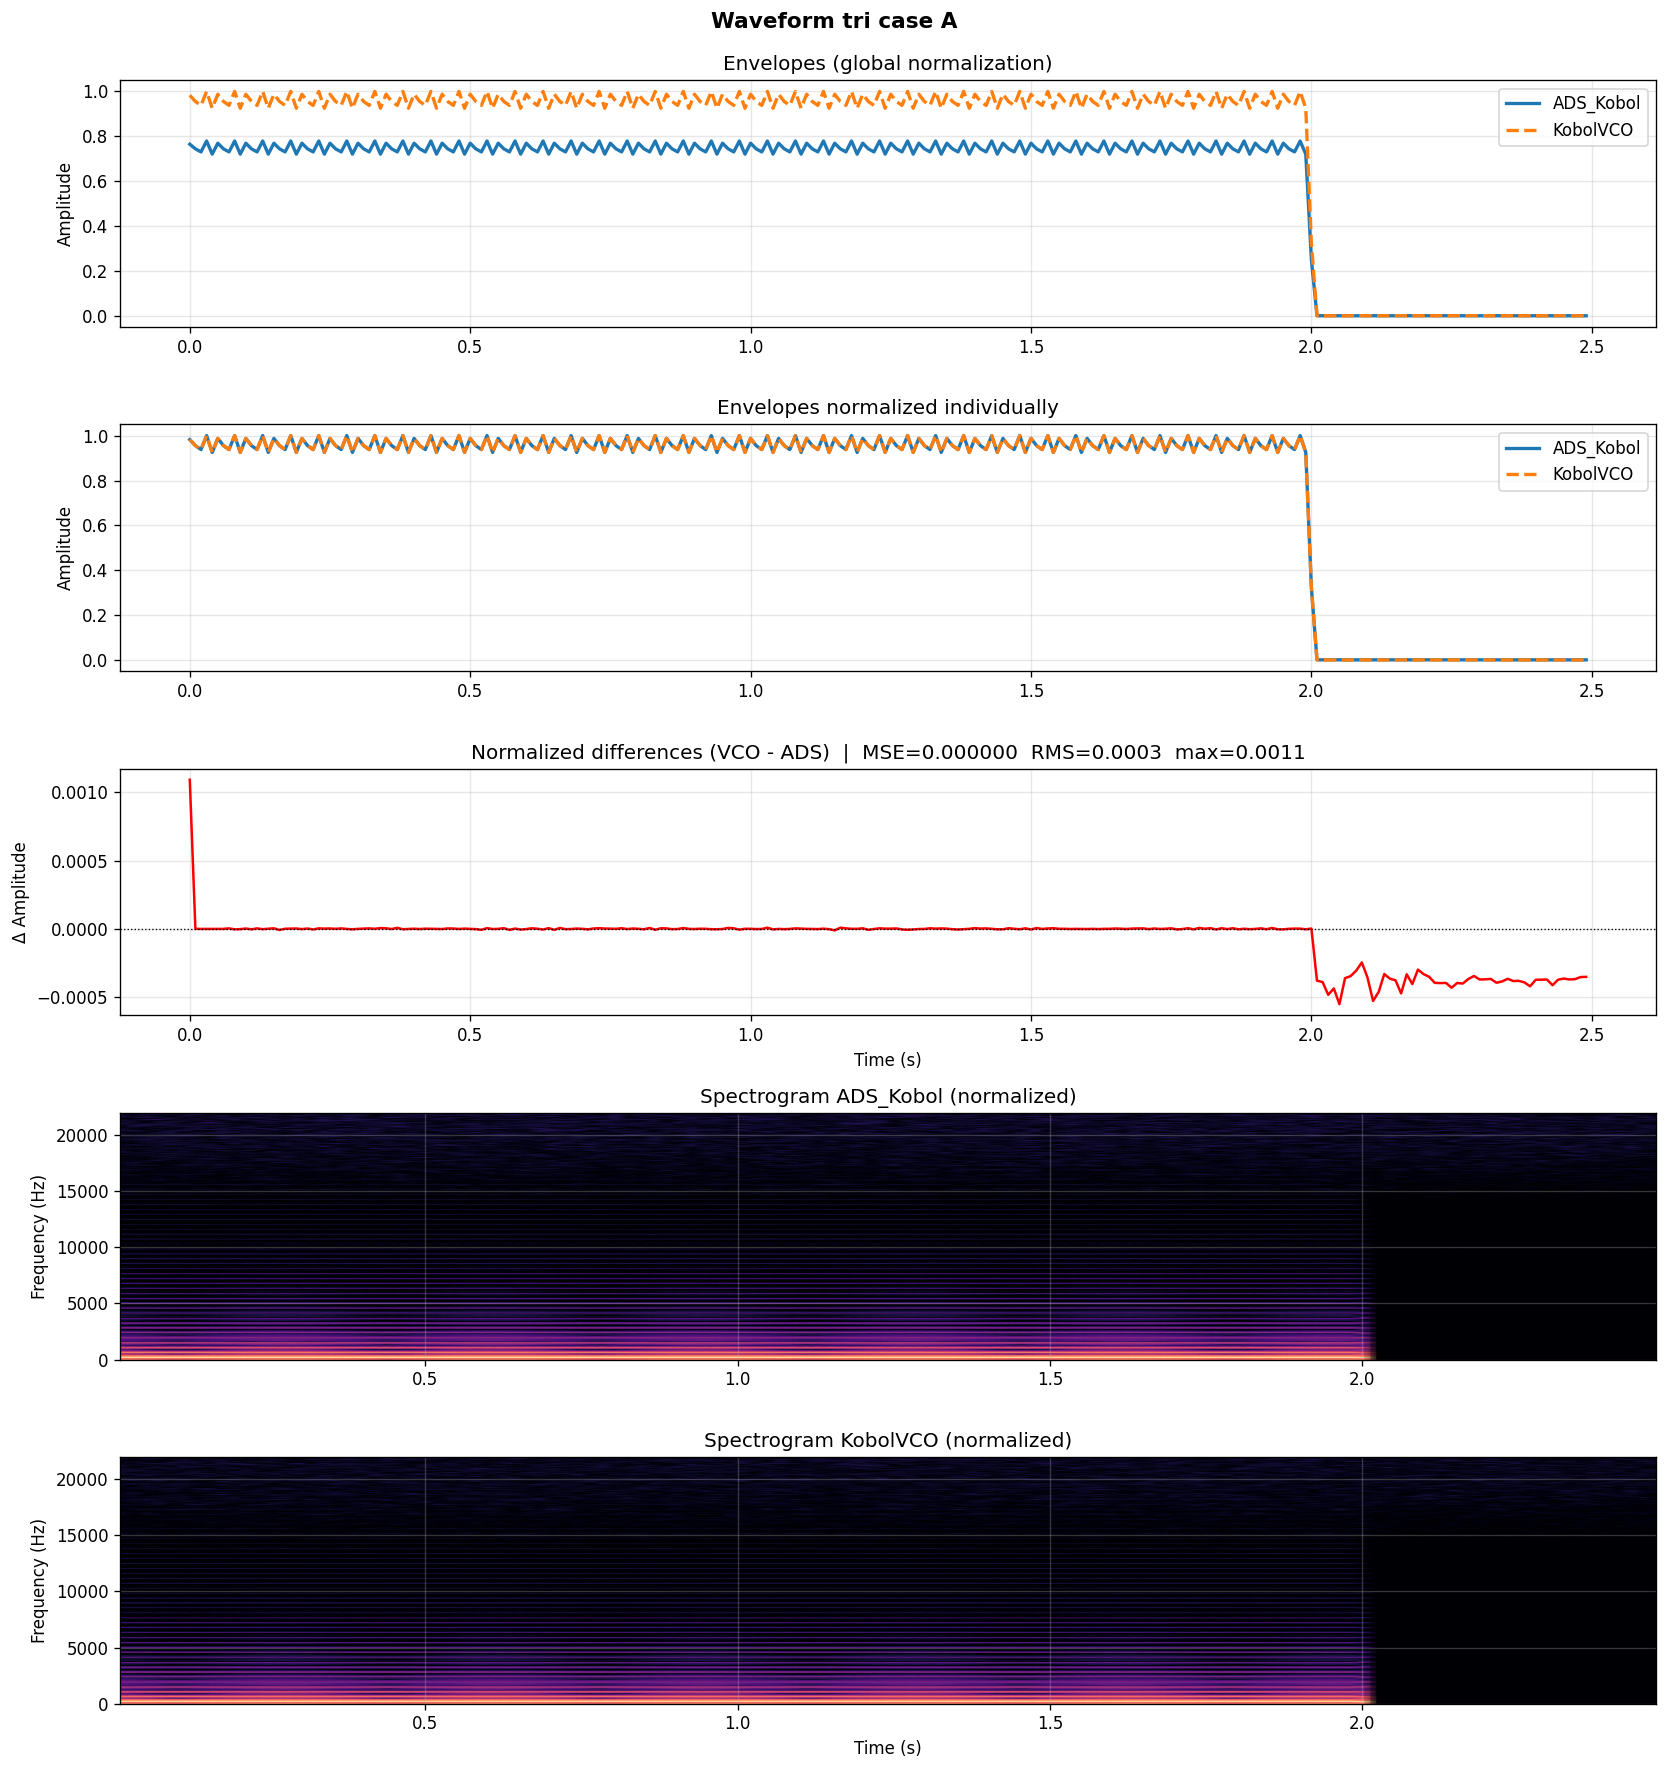

  Plot guardat: waveform_tri_case_a.png

  Analyzing: Waveform tri case B
  Lag detected: 0 samples (0.00 ms)

  — Differences —


,MSE,RMS,Max
Global,0.018691,0.1367,0.2007
Normalized,0.013190,0.1148,0.1897


  — Envelope Parameters —


,ADS_Kobol,KobolVCO
Attack (s),0.0000,0.0000
Decay (s),0.0100,0.0100
Sustain (% pic),70.9%,86.9%


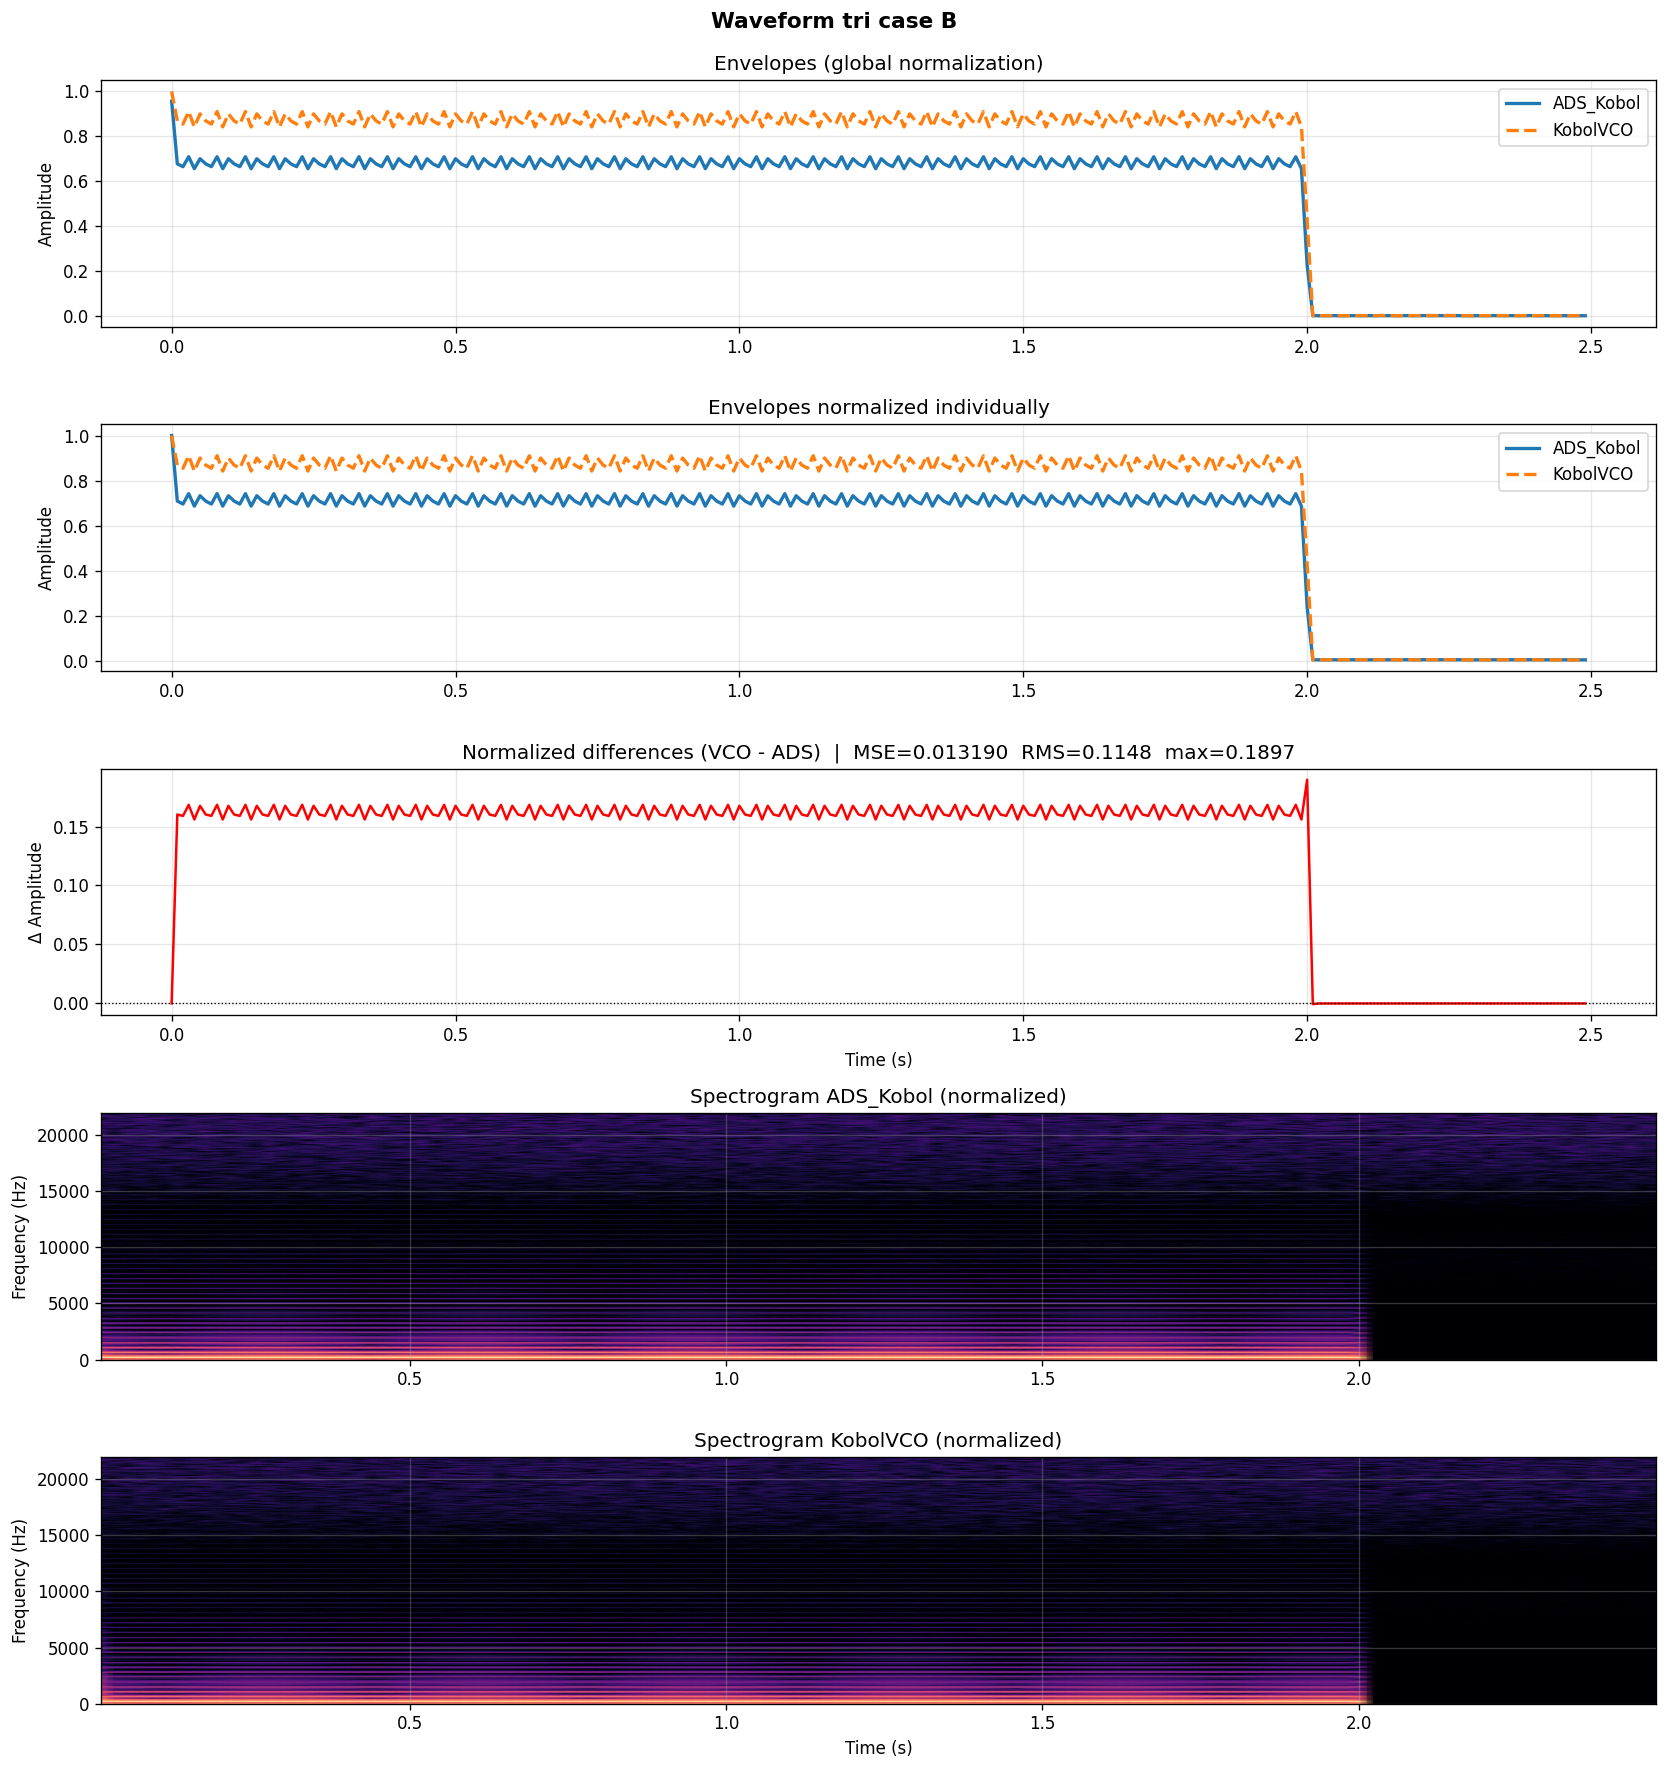

  Plot guardat: waveform_tri_case_b.png

  Analyzing: Waveform tri case C
  Lag detected: 0 samples (0.00 ms)

  — Differences —


,MSE,RMS,Max
Global,0.005816,0.0763,0.2930
Normalized,0.000589,0.0243,0.2513


  — Envelope Parameters —


,ADS_Kobol,KobolVCO
Attack (s),0.0100,0.0100
Decay (s),0.0300,0.0300
Sustain (% pic),48.2%,45.9%


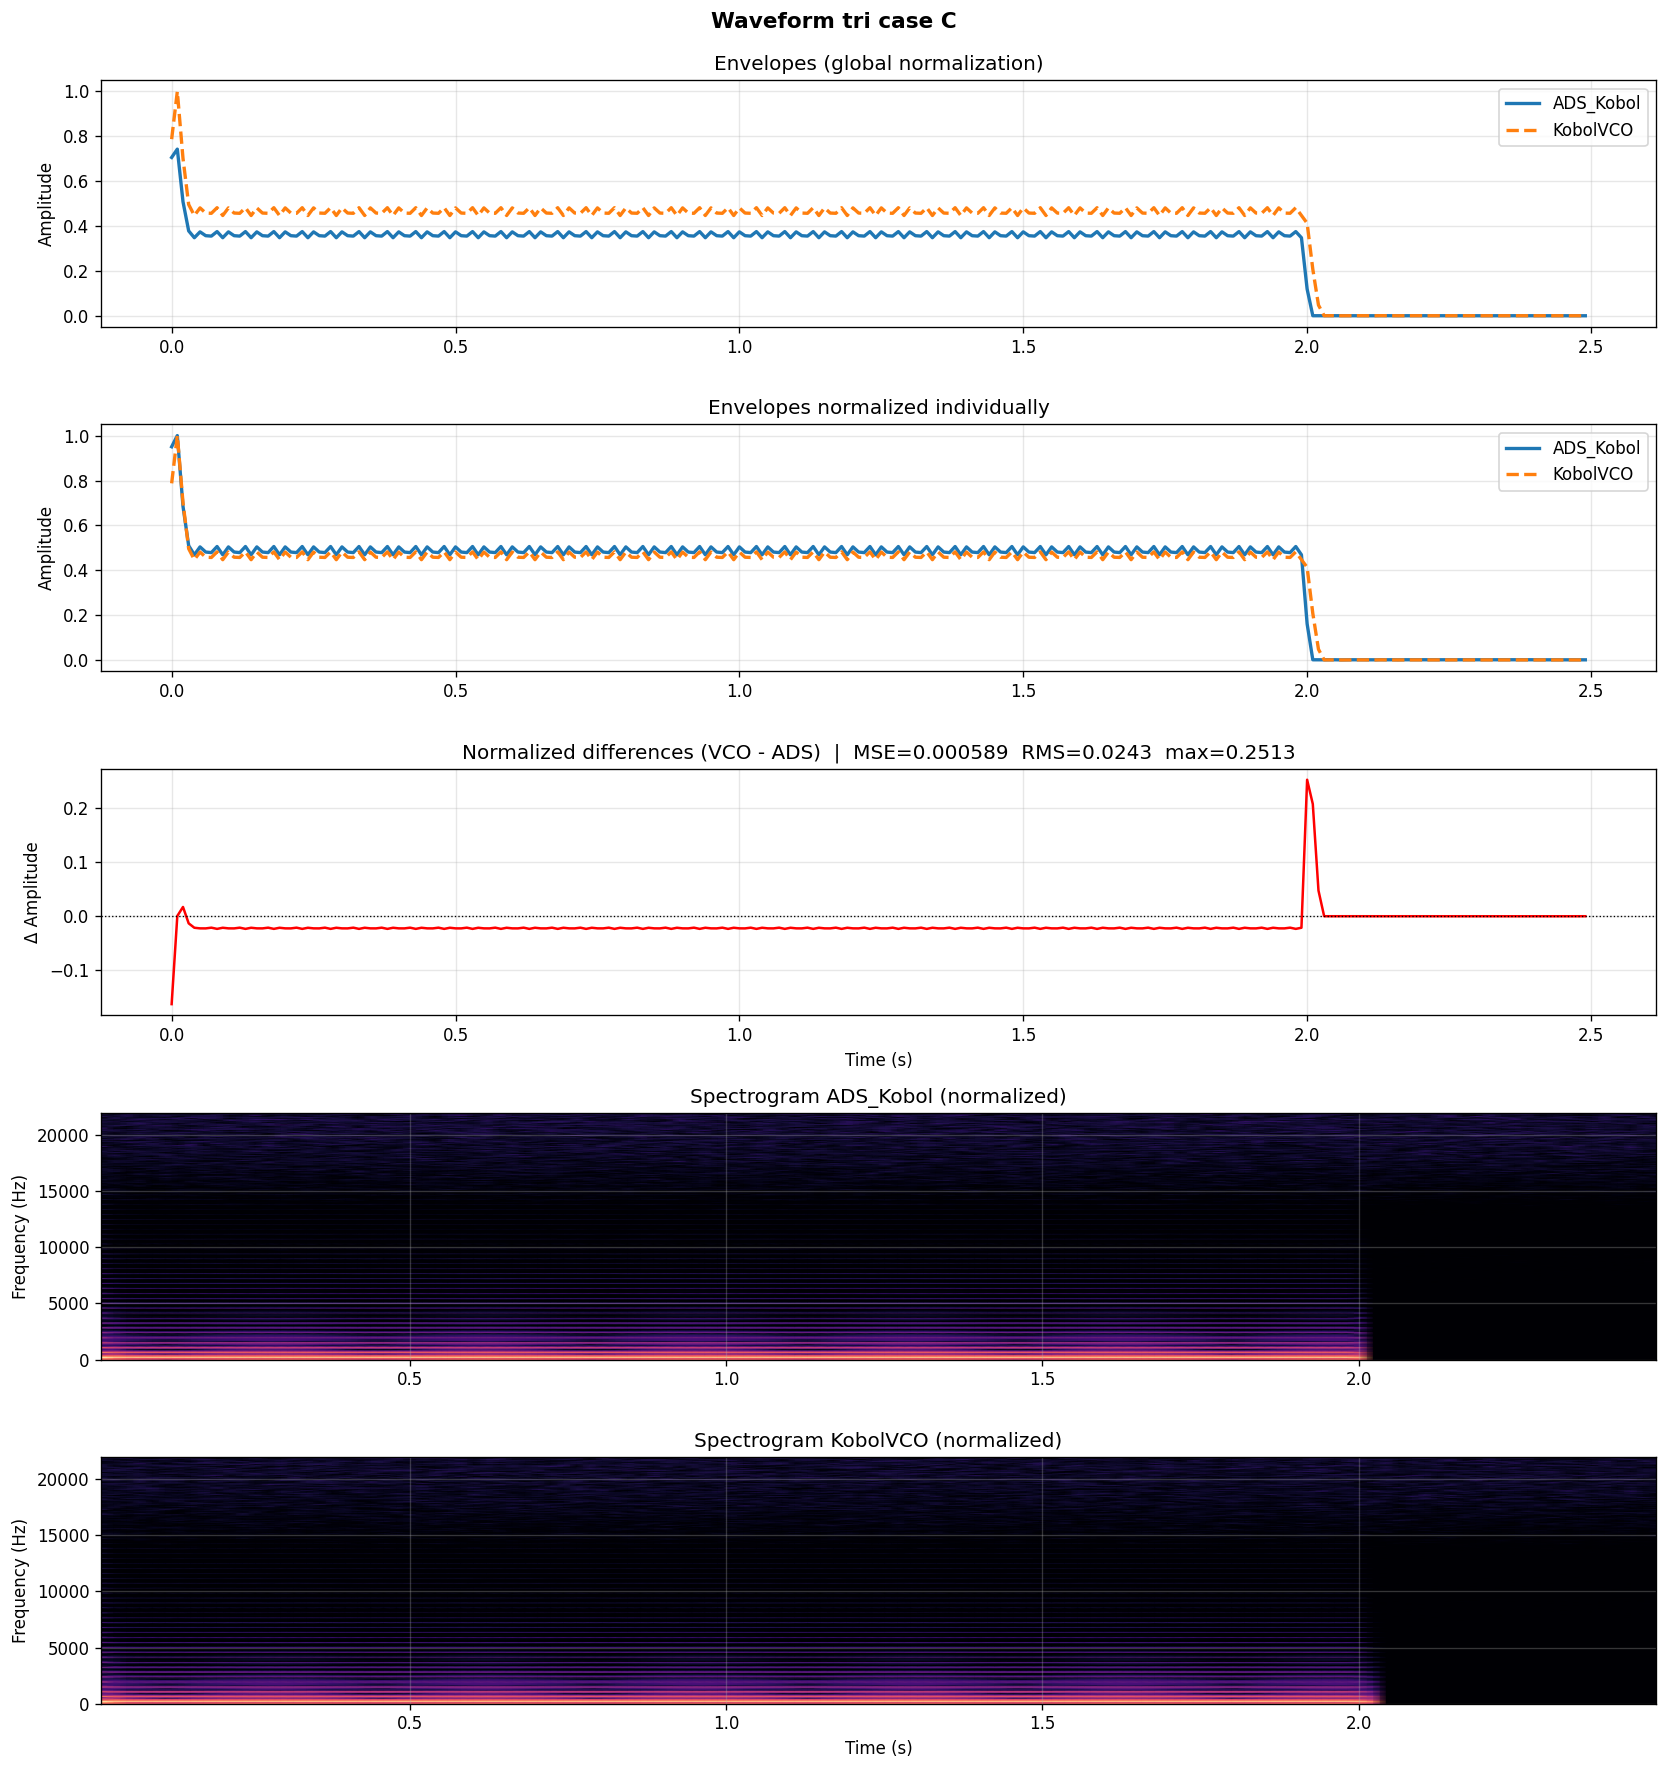

  Plot guardat: waveform_tri_case_c.png

  Analyzing: Waveform tri case D
  Lag detected: 0 samples (0.00 ms)

  — Differences —


,MSE,RMS,Max
Global,0.006620,0.0814,0.2250
Normalized,0.000158,0.0126,0.0819


  — Envelope Parameters —


,ADS_Kobol,KobolVCO
Attack (s),1.5500,1.5500
Decay (s),0.0700,0.0600
Sustain (% pic),67.8%,63.0%


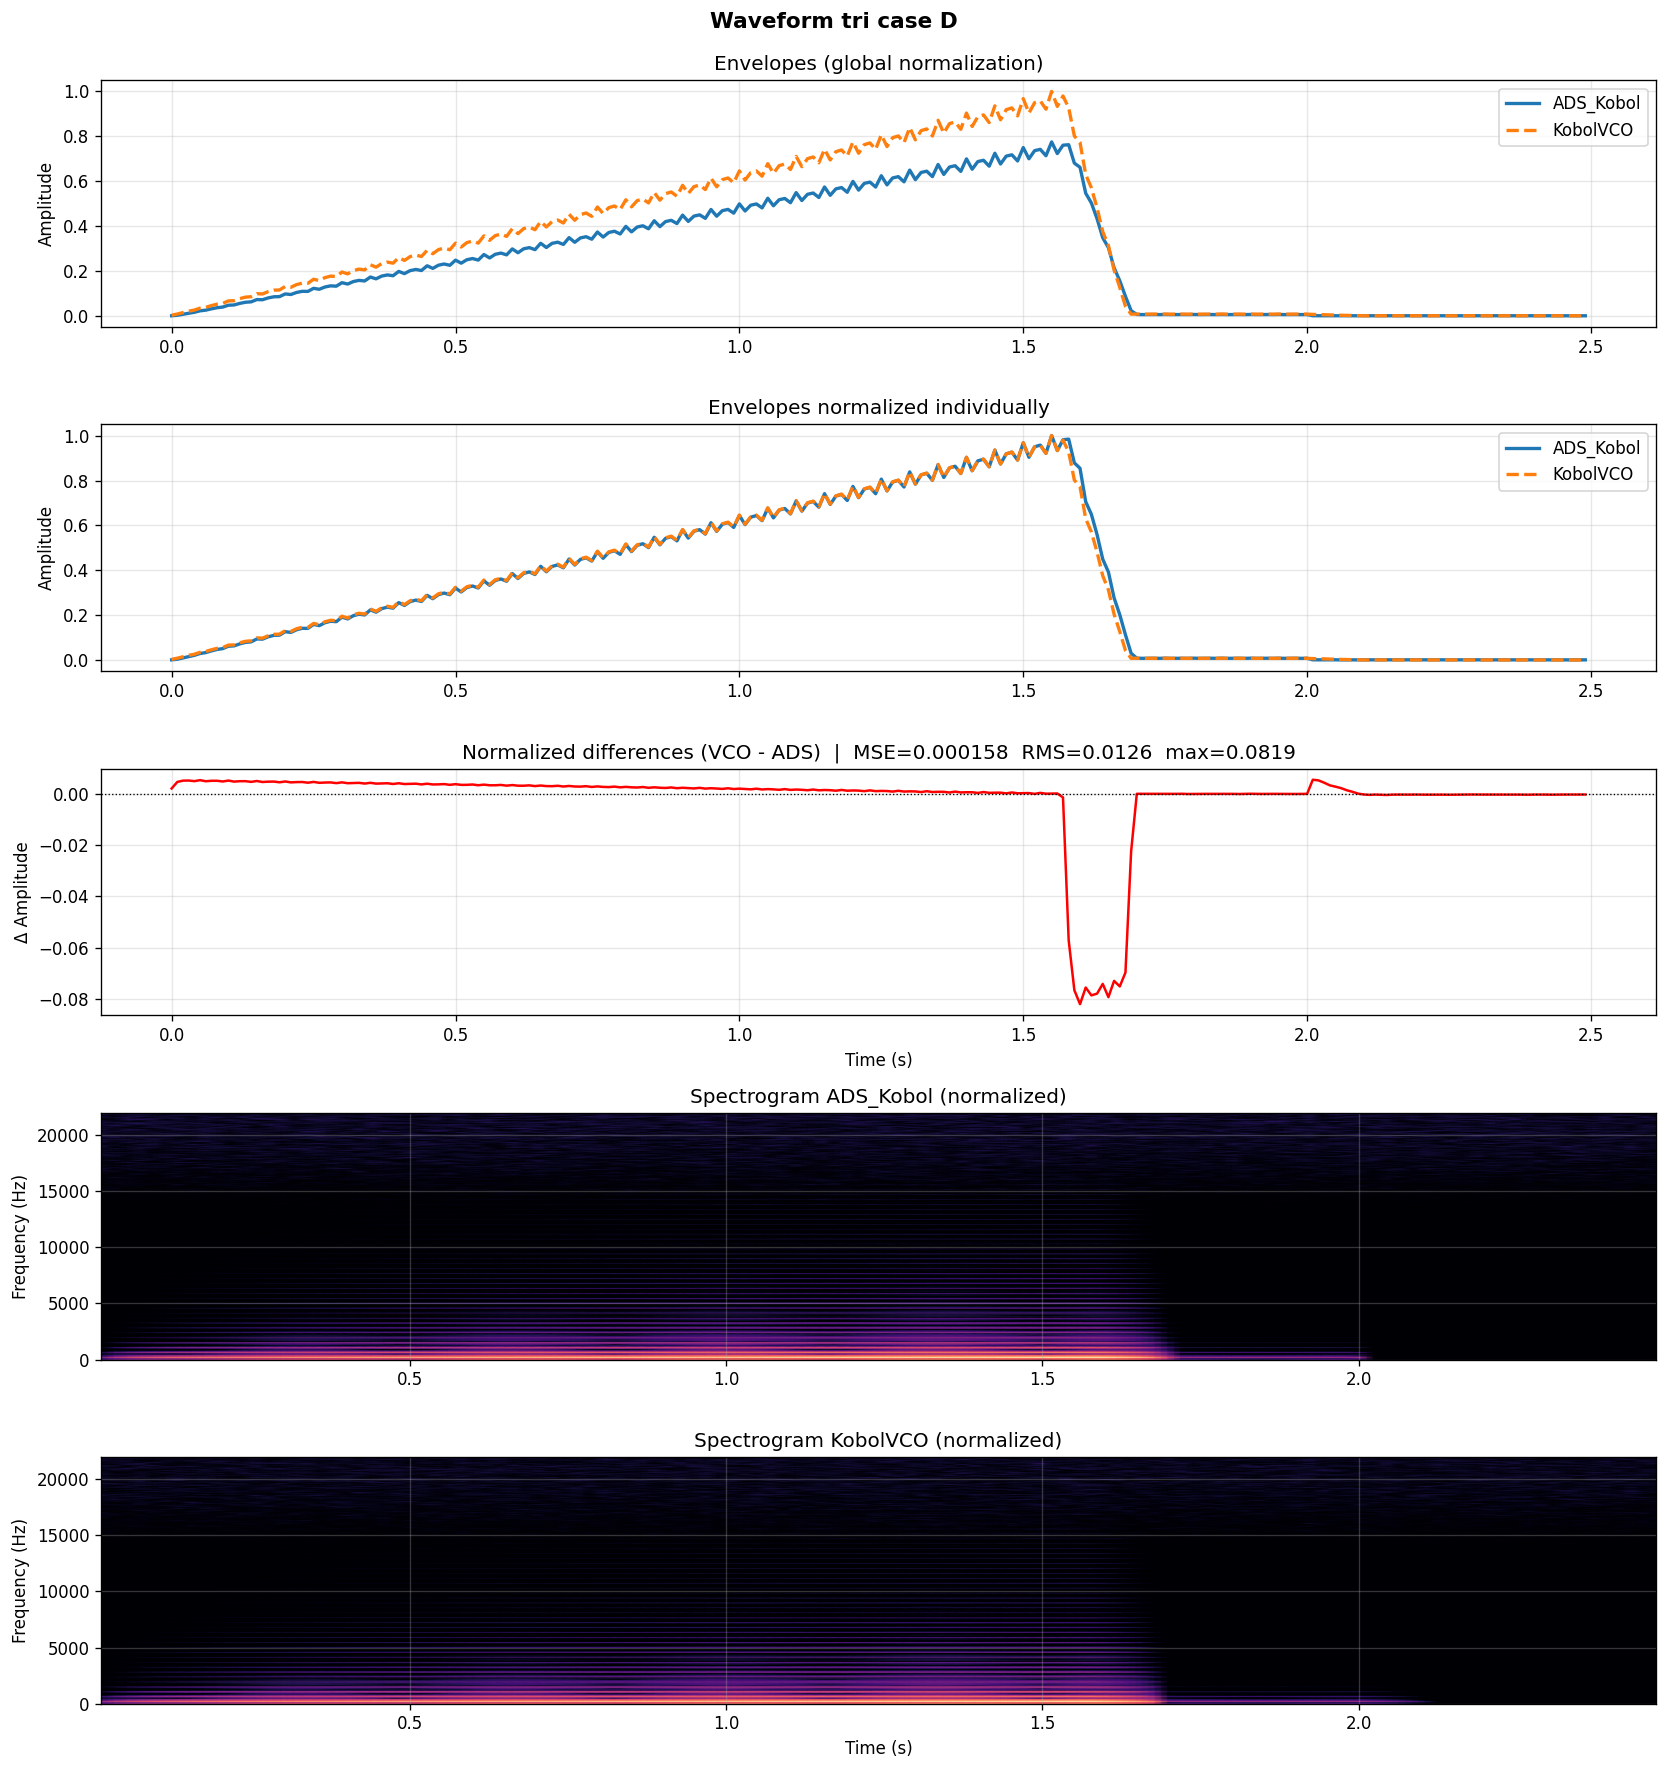

  Plot guardat: waveform_tri_case_d.png

  GLOBAL SUMMARY


,MSE normalized,RMS normalized,Max normalized,Δ Attack (s),Δ Decay (s),Sus ADS (%),Sus VCO (%)
Case,,,,,,,
Waveform tri case A,0.000000,0.0003,0.0011,0.0,0.00,95.500000,95.500000
Waveform tri case B,0.013190,0.1148,0.1897,0.0,0.00,70.900002,86.900002
Waveform tri case C,0.000589,0.0243,0.2513,0.0,0.00,48.200001,45.900002
Waveform tri case D,0.000158,0.0126,0.0819,0.0,-0.01,67.800003,63.000000



  Analyzing: Waveform saw case A
  Lag detected: 0 samples (0.00 ms)

  — Differences —


,MSE,RMS,Max
Global,0.021706,0.1473,0.2208
Normalized,0.000000,0.0001,0.0003


  — Envelope Parameters —


,ADS_Kobol,KobolVCO
Attack (s),0.0700,0.0700
Decay (s),0.0100,0.0100
Sustain (% pic),94.7%,94.7%


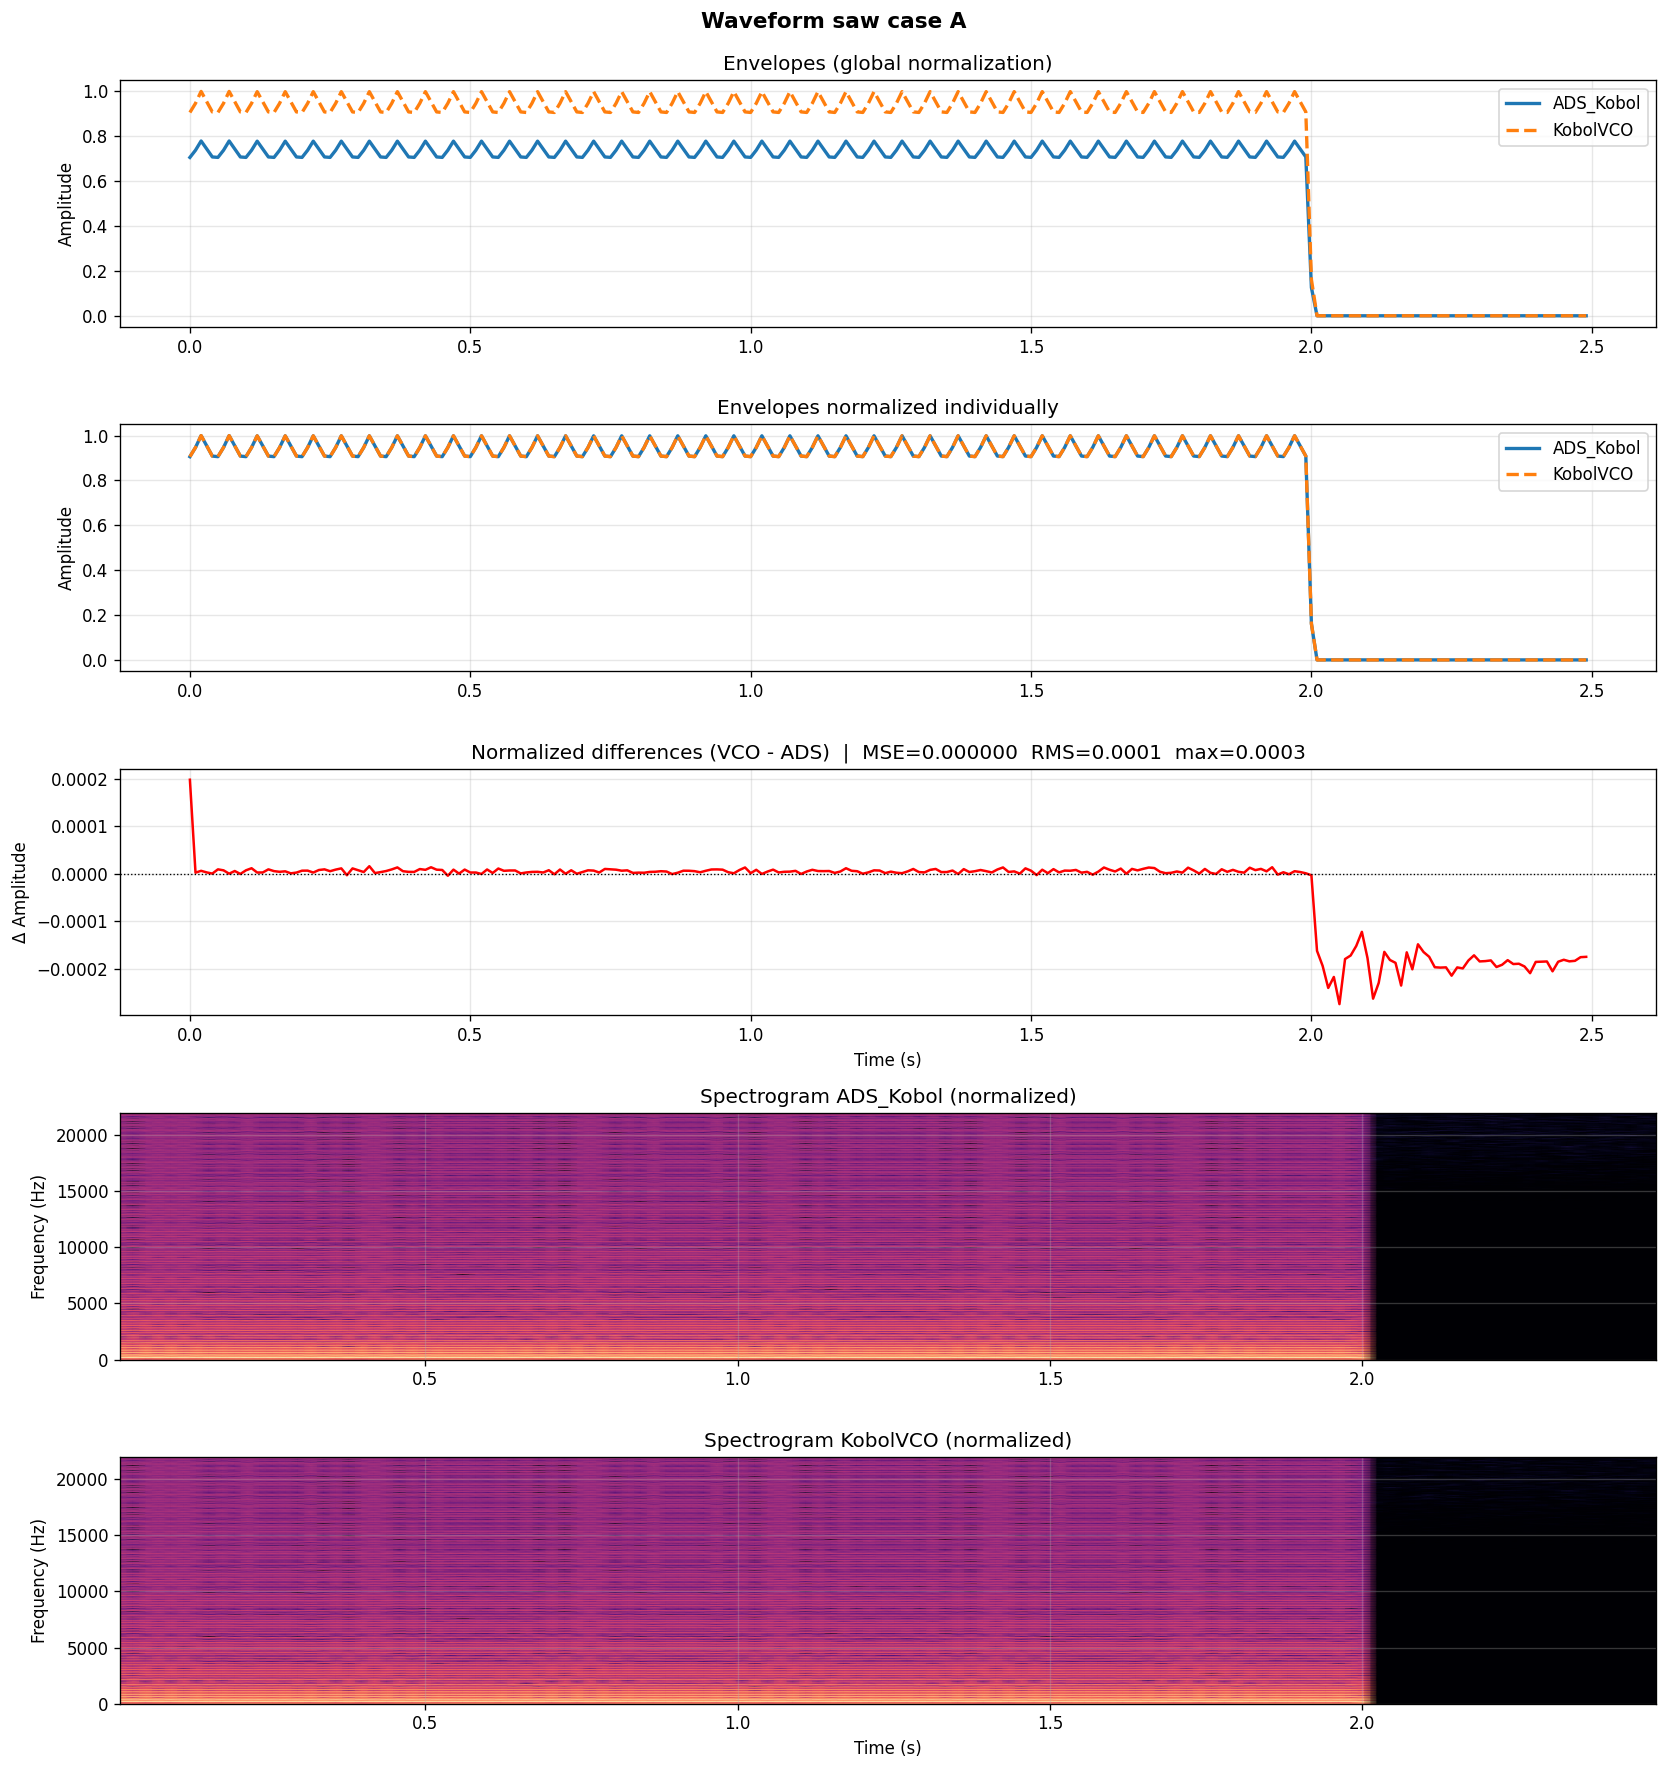

  Plot guardat: waveform_saw_case_a.png

  Analyzing: Waveform saw case B
  Lag detected: 0 samples (0.00 ms)

  — Differences —


,MSE,RMS,Max
Global,0.011630,0.1078,0.3740
Normalized,0.013797,0.1175,0.1760


  — Envelope Parameters —


,ADS_Kobol,KobolVCO
Attack (s),0.0000,0.0000
Decay (s),0.0100,0.0100
Sustain (% pic),85.1%,68.3%


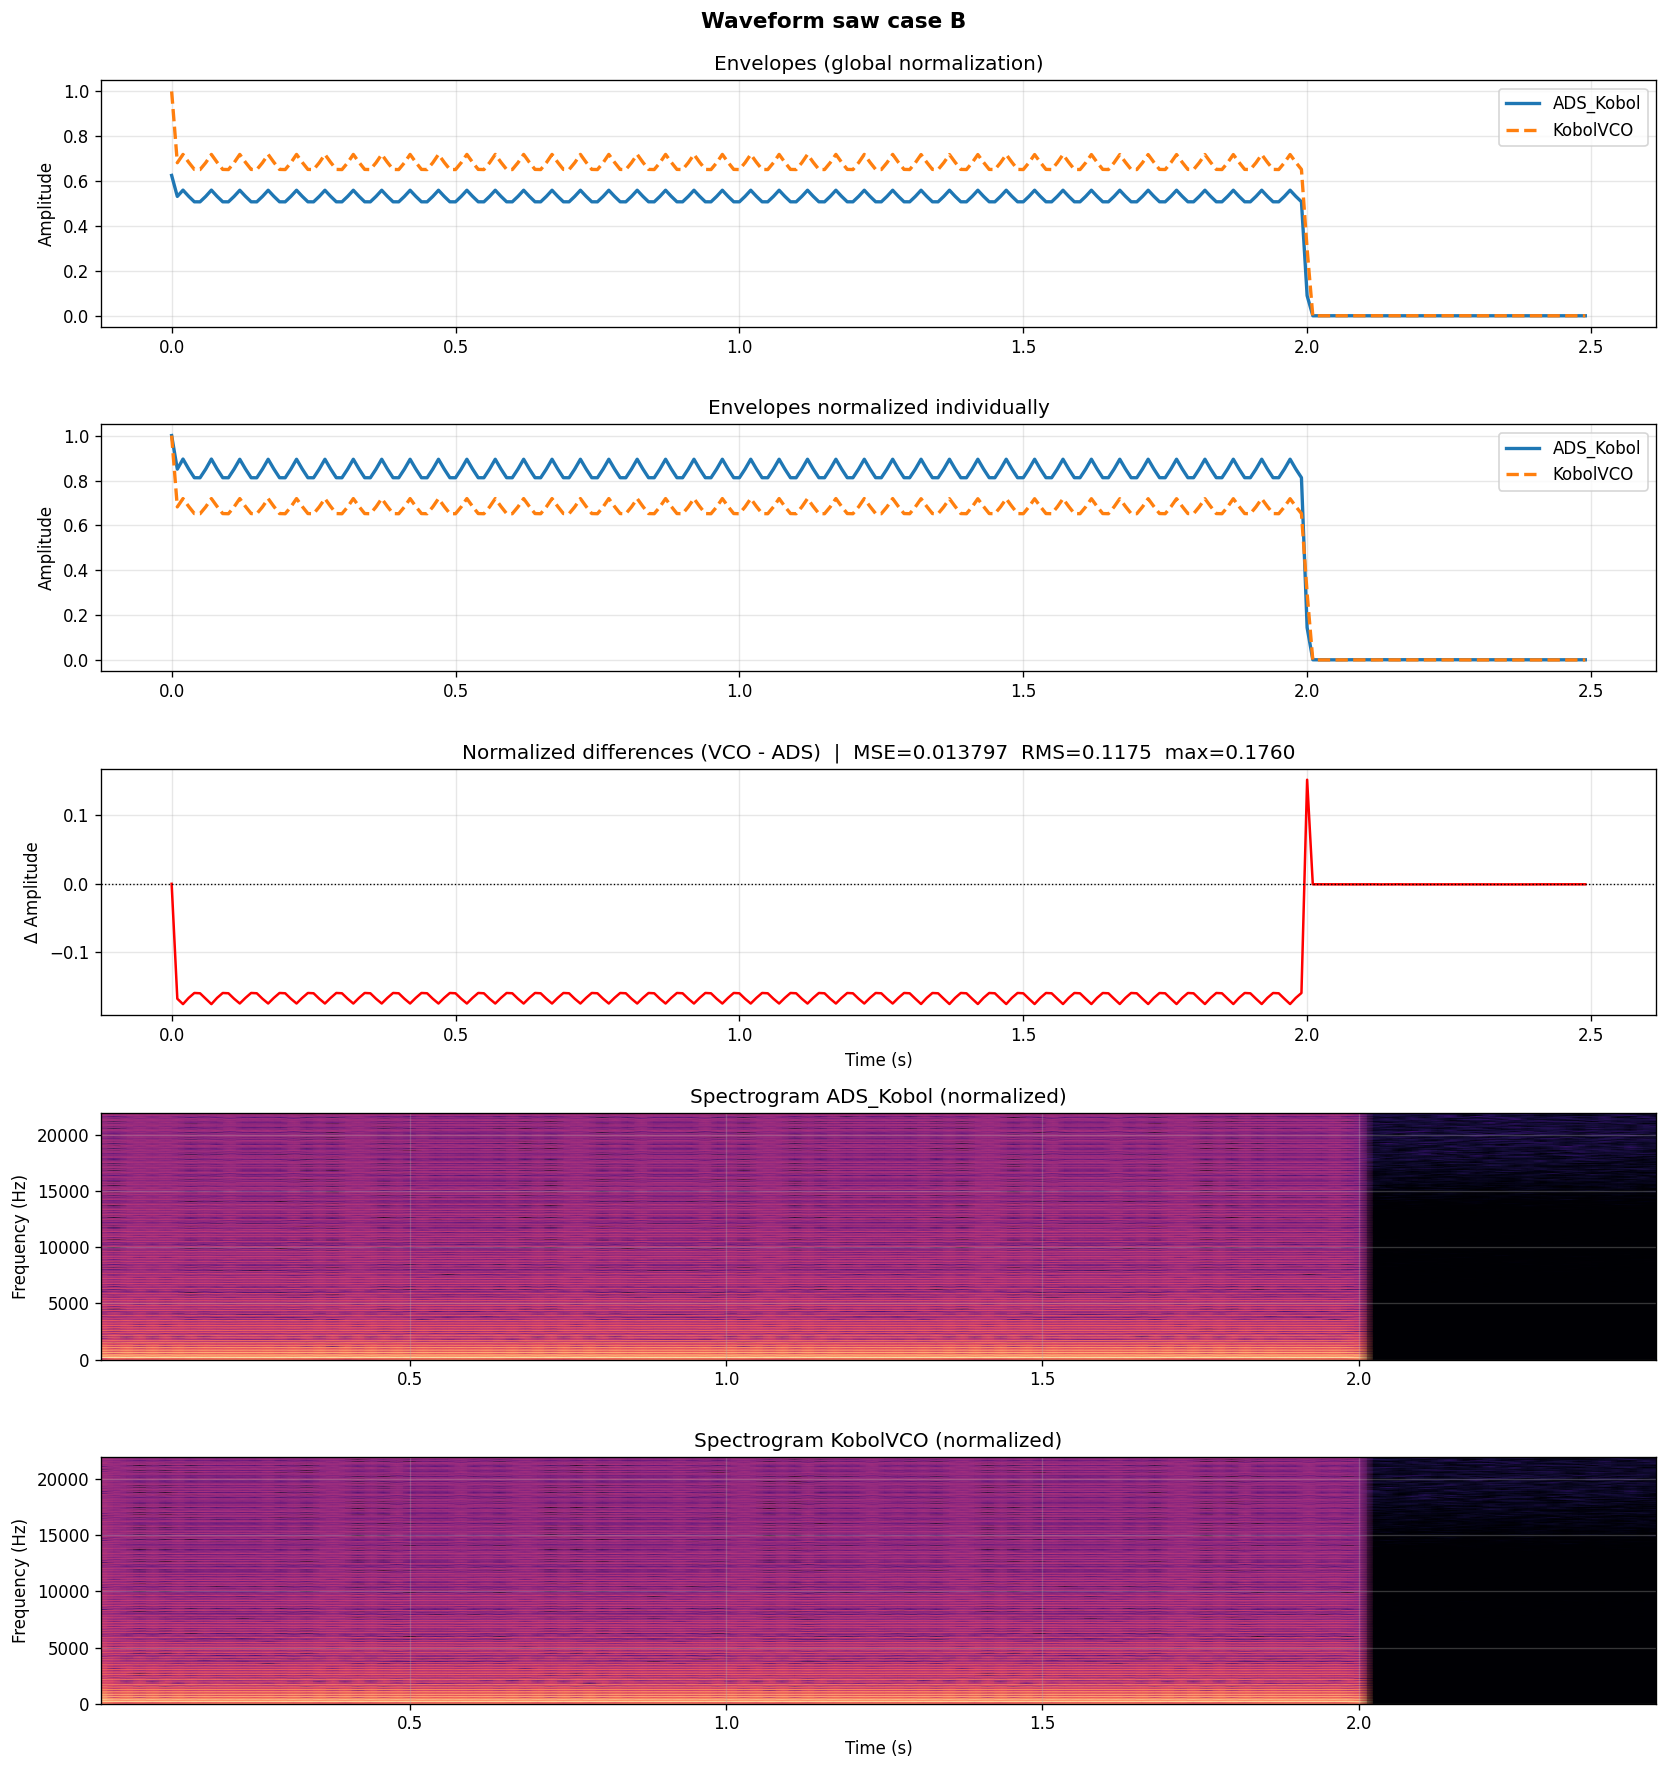

  Plot guardat: waveform_saw_case_b.png

  Analyzing: Waveform saw case C
  Lag detected: 0 samples (0.00 ms)

  — Differences —


,MSE,RMS,Max
Global,0.006603,0.0813,0.3082
Normalized,0.000625,0.0250,0.1980


  — Envelope Parameters —


,ADS_Kobol,KobolVCO
Attack (s),0.0100,0.0000
Decay (s),0.0500,0.0300
Sustain (% pic),47.3%,50.1%


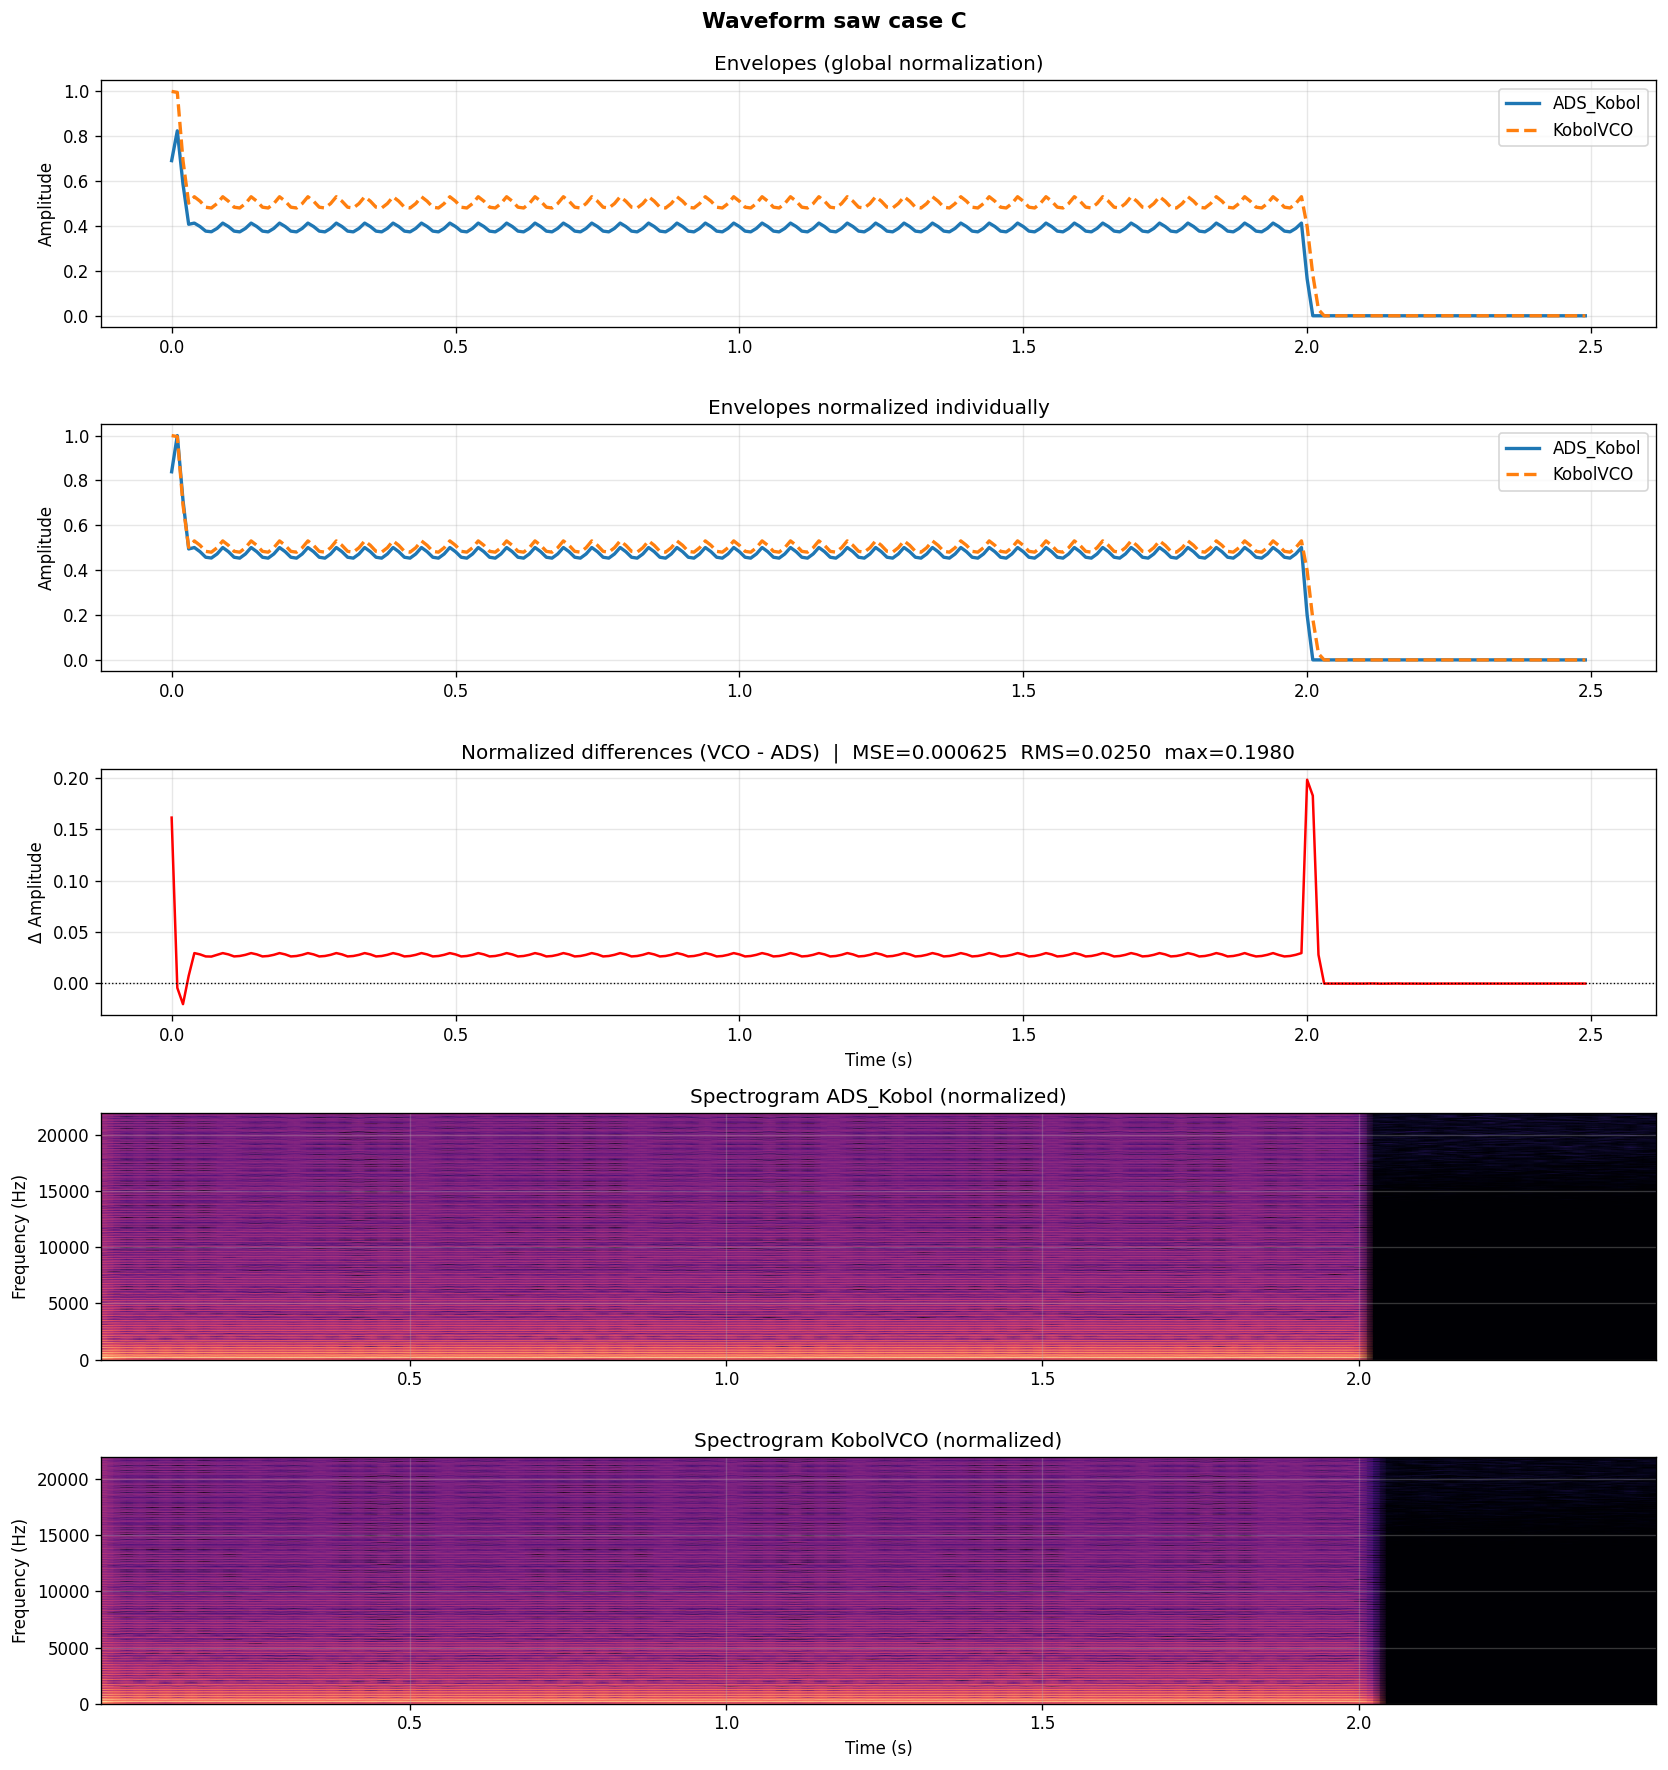

  Plot guardat: waveform_saw_case_c.png

  Analyzing: Waveform saw case D
  Lag detected: 0 samples (0.00 ms)

  — Differences —


,MSE,RMS,Max
Global,0.006358,0.0797,0.2204
Normalized,0.000004,0.0021,0.0125


  — Envelope Parameters —


,ADS_Kobol,KobolVCO
Attack (s),1.5600,1.5600
Decay (s),0.0600,0.0600
Sustain (% pic),59.3%,60.5%


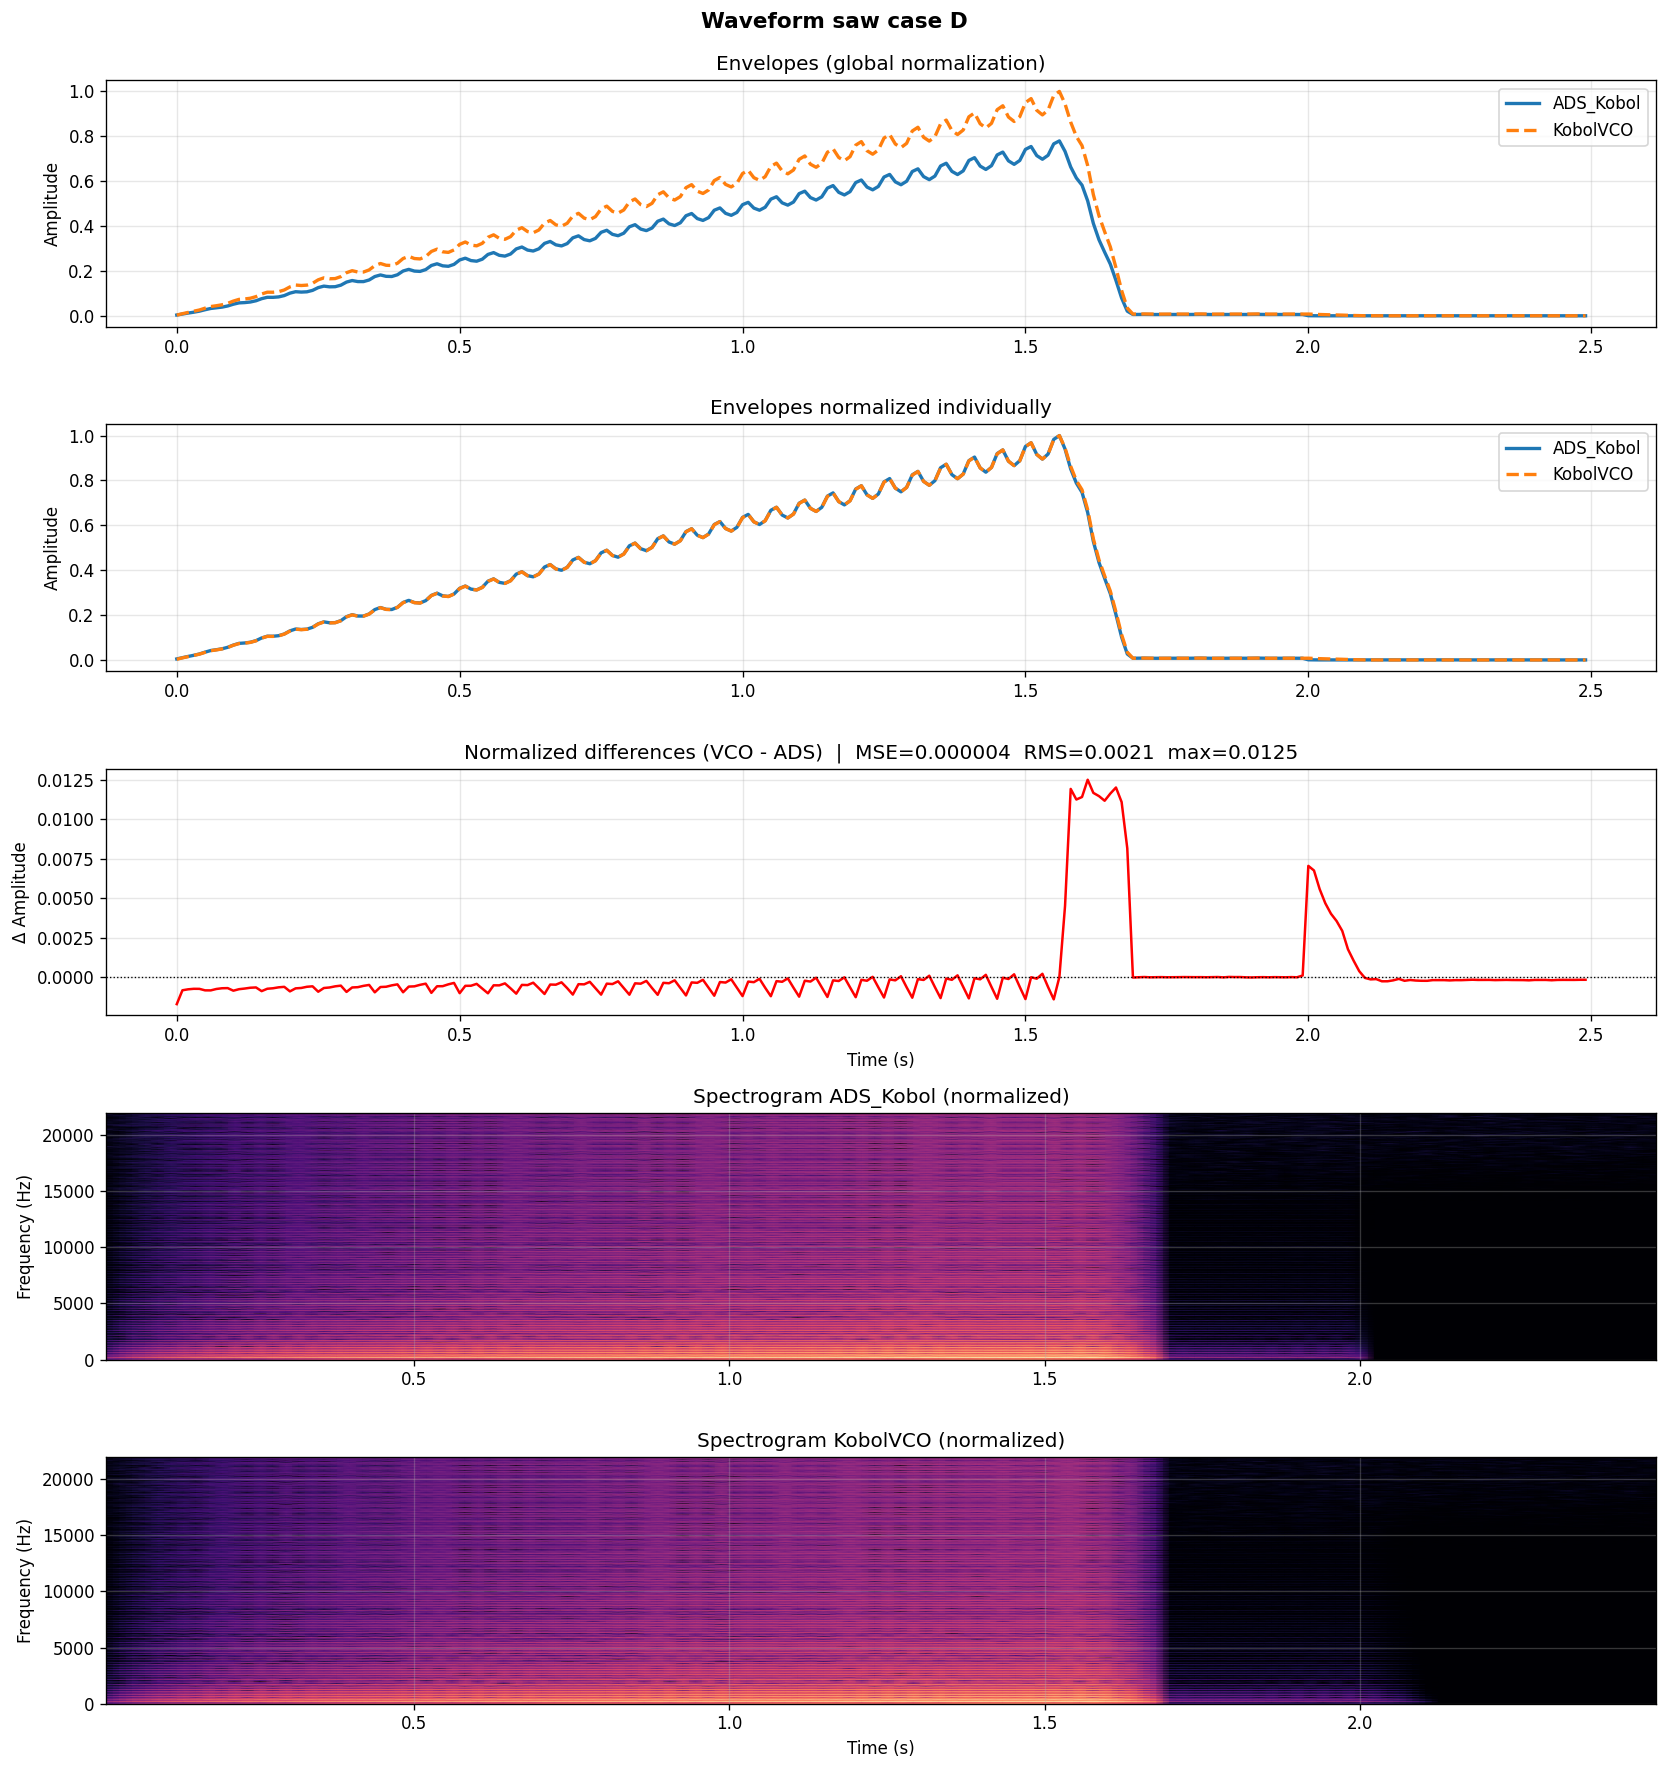

  Plot guardat: waveform_saw_case_d.png

  GLOBAL SUMMARY


,MSE normalized,RMS normalized,Max normalized,Δ Attack (s),Δ Decay (s),Sus ADS (%),Sus VCO (%)
Case,,,,,,,
Waveform tri case A,0.000000,0.0003,0.0011,0.00,0.00,95.500000,95.500000
Waveform tri case B,0.013190,0.1148,0.1897,0.00,0.00,70.900002,86.900002
Waveform tri case C,0.000589,0.0243,0.2513,0.00,0.00,48.200001,45.900002
Waveform tri case D,0.000158,0.0126,0.0819,0.00,-0.01,67.800003,63.000000
Waveform saw case A,0.000000,0.0001,0.0003,0.00,0.00,94.699997,94.699997
Waveform saw case B,0.013797,0.1175,0.1760,0.00,0.00,85.099998,68.300003
Waveform saw case C,0.000625,0.0250,0.1980,-0.01,-0.02,47.299999,50.099998
Waveform saw case D,0.000004,0.0021,0.0125,0.00,0.00,59.299999,60.500000


In [5]:
# ─────────────────────────────────────────────────────────────────
# ANALYSIS
# ─────────────────────────────────────────────────────────────────

RECORDINGS_DIR = 'C:/Users/jordi/Documentos/00-UPF/05-TFG/Juce files/TFGKobolLocal/PluginRecordings/VCO+VCA/aligned/'

# Check if the folder exists
if not os.path.isdir(RECORDINGS_DIR):
    print(f"⚠️  Folder '{RECORDINGS_DIR}' not found.")
else:
    results = []
    for wf in ['tri', 'saw']:
        for case_id in ['A', 'B', 'C', 'D']:
            p_ref = os.path.join(RECORDINGS_DIR, f'{wf}_ref.wav')
            p_ads = os.path.join(RECORDINGS_DIR, f'{wf}_{case_id}_kobol_ads.wav')
            p_vco = os.path.join(RECORDINGS_DIR, f'{wf}_{case_id}_kobol_vco.wav')

            if all(os.path.isfile(p) for p in [p_ref, p_ads, p_vco]):
                metrics = analyse_case(f"Waveform {wf} case {case_id}", p_ads, p_vco)
                results.append(metrics)
            else:
                print(f"⚠️  Files missing for Case {case_id}, skipping...")

        # Global Summary
        if results:
            print('\n' + '='*60)
            print('  GLOBAL SUMMARY')
            print('='*60)

            df_resum = pd.DataFrame([{
                'Case':         r['case'],
                'MSE normalized':    round(r['mse_diff_n'], 6),
                'RMS normalized':    round(r['rms_diff_n'], 4),
                'Max normalized':    round(r['max_diff_n'], 4),
                'Δ Attack (s)': round(r['attack_vco'] - r['attack_ads'], 4),
                'Δ Decay (s)':  round(r['decay_vco']  - r['decay_ads'],  4),
                'Sus ADS (%)':  round(r['sustain_ads'], 1),
                'Sus VCO (%)':  round(r['sustain_vco'], 1),
            } for r in results]).set_index('Case')

            display(df_resum)